**Q1. What is Deep Learning? Briefly describe how it evolved and how it differs from traditional machine learning.**
Answer:

* **Deep Learning** is a subset of **Machine Learning** that uses **artificial neural networks with multiple hidden layers** to learn patterns from large amounts of data.
* It is inspired by the **structure of the human brain**.
* It evolved from early neural network research in the **1950s**, but became powerful after **2010** due to large datasets and high computing power (GPUs).
* Traditional Machine Learning requires **manual feature extraction**, while Deep Learning automatically learns features from raw data.
* *Example: In image recognition, traditional ML needs manual feature selection like edges and shapes, while Deep Learning learns these features automatically.*

**Q2. Explain the basic architecture and functioning of a Perceptron. What are its limitations?**
Answer:

* A **Perceptron** is the simplest type of **artificial neural network**, developed by Frank Rosenblatt.
* It consists of **input values, weights, bias, summation, and an activation function**.
* It calculates a weighted sum of inputs and passes it through an activation function to produce output.
* Formula: Output = Activation(Weighted Sum + Bias).
* *Example: It can classify emails as spam or not spam based on input features.*

**Limitations:**

* It can only solve **linearly separable problems**.
* It cannot solve complex problems like the **XOR problem**.
* It uses only a **single layer**, so it cannot model complex patterns.

**Q3. Describe the purpose of activation function in neural networks. Compare Sigmoid, ReLU, and Tanh functions.**
Answer:

* An **activation function** introduces **non-linearity** into the neural network.
* Without activation functions, the network would behave like a simple linear model.
* It helps the model learn **complex patterns**.

**Sigmoid Function:**

* Output range: **0 to 1**.
* Used in binary classification.
* Problem: **Vanishing gradient issue**.
* *Example: Used in output layer for yes/no prediction.*

**Tanh Function:**

* Output range: **-1 to 1**.
* Zero-centered, better than sigmoid in some cases.
* Still suffers from **vanishing gradient**.

**ReLU (Rectified Linear Unit):**

* Output: 0 for negative values, positive value remains same.
* Faster and widely used in hidden layers.
* Problem: **Dying ReLU issue**.
* *Example: Most deep learning hidden layers use ReLU.*

**Q4. What is the difference between Loss function and Cost function in neural networks? Provide examples.**
Answer:

* A **Loss Function** measures the error for a **single training example**.
* A **Cost Function** is the **average of loss values over the entire dataset**.
* Loss is calculated per sample, while cost represents overall model performance.

*Example:*

* In binary classification, **Binary Cross-Entropy** is used as loss.
* The average of all individual losses becomes the **Cost** during training.

Another example:

* **Mean Squared Error (MSE)** is commonly used in regression problems.

**Q5. What is the role of optimizers in neural networks? Compare Gradient Descent, Adam, and RMSprop.**
Answer:

* **Optimizers** are algorithms used to **update weights and minimize the loss function**.
* They help the model learn by adjusting weights in the direction of minimum error.

**Gradient Descent:**

* Updates weights using the **gradient of the loss function**.
* Simple but can be slow.
* *Example: Basic linear regression training.*

**RMSprop:**

* Adjusts learning rate automatically for each parameter.
* Works well for non-stationary problems.
* Faster than basic gradient descent.

**Adam (Adaptive Moment Estimation):**

* Combines advantages of **Momentum and RMSprop**.
* Uses adaptive learning rate.
* Fast and widely used in deep learning models.
* *Example: Commonly used in CNNs and NLP models.*



In [1]:
'''
Q6. Write a Python program to implement a single-layer perceptron from scratch using NumPy to solve the logical AND gate.
'''
import numpy as np

# AND gate dataset
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([0,0,0,1])

# Initialize weights and bias
weights = np.zeros(2)
bias = 0
learning_rate = 0.1
epochs = 10

# Step activation function
def step(x):
    return 1 if x >= 0 else 0

# Training
for _ in range(epochs):
    for i in range(len(X)):
        linear_output = np.dot(X[i], weights) + bias
        prediction = step(linear_output)
        error = y[i] - prediction

        weights += learning_rate * error * X[i]
        bias += learning_rate * error

# Testing
print("Predictions for AND Gate:")
for i in range(len(X)):
    linear_output = np.dot(X[i], weights) + bias
    print(X[i], "->", step(linear_output))

Predictions for AND Gate:
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


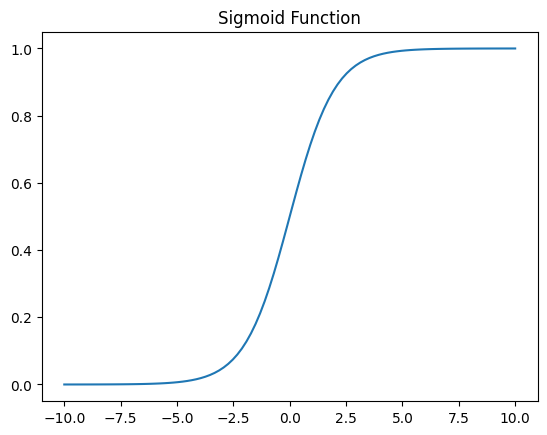

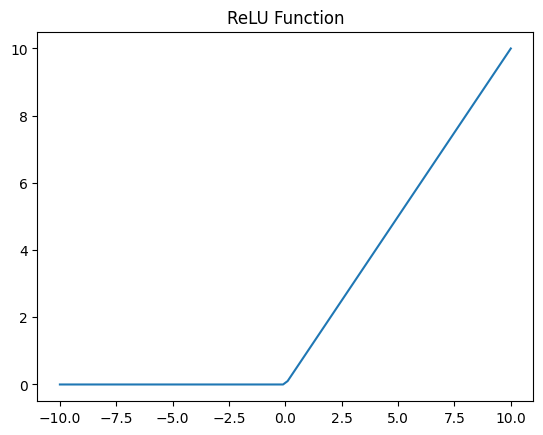

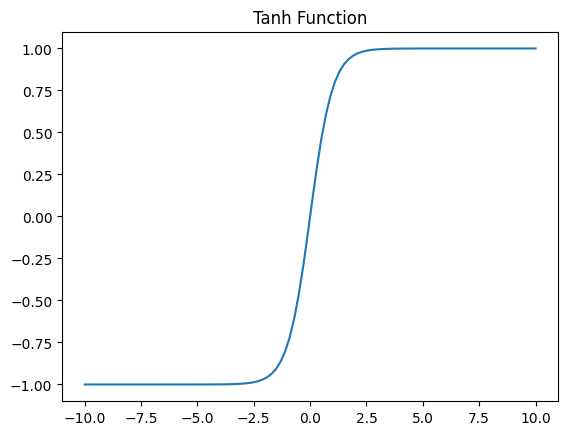

In [2]:
'''Q7. Implement and visualize Sigmoid, ReLU, and Tanh activation functions using Matplotlib.'''
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)

sigmoid = 1 / (1 + np.exp(-x))
relu = np.maximum(0, x)
tanh = np.tanh(x)

plt.figure()
plt.plot(x, sigmoid)
plt.title("Sigmoid Function")
plt.show()

plt.figure()
plt.plot(x, relu)
plt.title("ReLU Function")
plt.show()

plt.figure()
plt.plot(x, tanh)
plt.title("Tanh Function")
plt.show()

In [3]:
'''
Q8. Use Keras to build and train a simple multilayer neural network on the MNIST digits dataset. Print the training accuracy.
'''
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalize data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Build model
model = keras.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

# Print training accuracy
print("Training Accuracy:", history.history['accuracy'][-1])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8565 - loss: 0.4868 - val_accuracy: 0.9563 - val_loss: 0.1475
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9632 - loss: 0.1234 - val_accuracy: 0.9651 - val_loss: 0.1150
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9762 - loss: 0.0786 - val_accuracy: 0.9692 - val_loss: 0.1005
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9820 - loss: 0.0580 - val_accuracy: 0.9712 - val_loss: 0.0992
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9864 - loss: 0.0425 - val_accuracy: 0.9728 - val_loss: 0.0974
Training Accuracy: 0.98458331823349


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7724 - loss: 0.6631 - val_accuracy: 0.8525 - val_loss: 0.4145
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8613 - loss: 0.3836 - val_accuracy: 0.8672 - val_loss: 0.3685
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8711 - loss: 0.3471 - val_accuracy: 0.8688 - val_loss: 0.3644
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8814 - loss: 0.3252 - val_accuracy: 0.8799 - val_loss: 0.3373
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8884 - loss: 0.3020 - val_accuracy: 0.8798 - val_loss: 0.3306


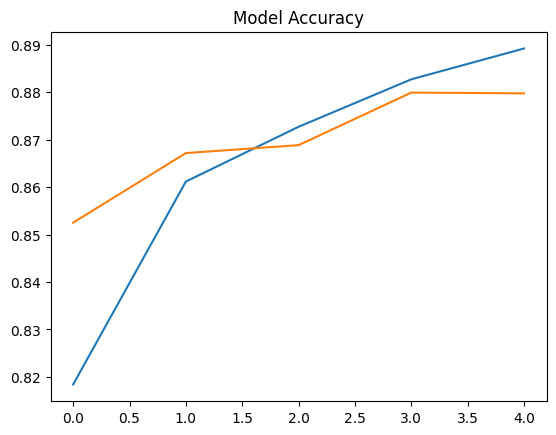

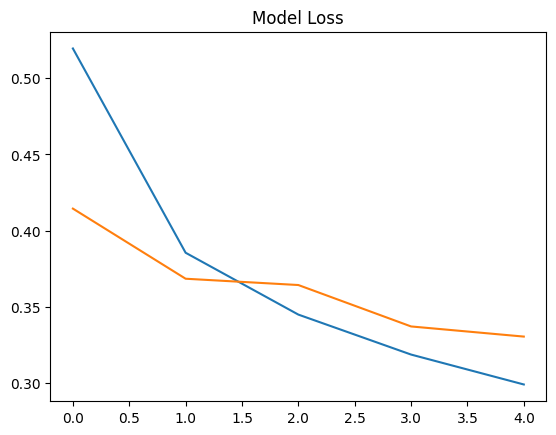

In [4]:
'''
Q9. Visualize the loss and accuracy curves for a neural network model trained on the Fashion MNIST dataset. Interpret the training behavior.
'''
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

# Load dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

model = keras.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

# Plot Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.show()

# Plot Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.show()


Question 10: You are working on a project for a bank that wants to automatically detectfraudulent transactions. The dataset is large, imbalanced, and contains structured features like transaction amount, merchant ID, and customer location. The goal is to classify each transaction as fraudulent or legitimate.

Explain your real-time data science workflow:

* How would you design a deep learning model (perceptron or multilayer NN)?

* Which activation function and loss function would you use, and why?

* How would you train and evaluate the model, considering class imbalance?

* Which optimizer would be suitable, and how would you prevent overfitting?
(Include your Python code and output in the code box below.)

**Q10. Fraud Detection in Banking using Deep Learning – Real-Time Data Science Workflow**
Answer:

**1. Model Design (Multilayer Neural Network):**

* Since the dataset contains **structured numerical features** (transaction amount, merchant ID, location), I would use a **Multilayer Neural Network (MLP)** instead of a single perceptron.
* A perceptron can only handle **linear relationships**, but fraud detection requires learning **complex non-linear patterns**.
* The model architecture would include:

  * Input layer (number of features)
  * 2–3 hidden layers with ReLU
  * Output layer with 1 neuron (binary classification)

*Example: Detecting unusual patterns like high transaction amount + unusual location + new merchant combination.*

**2. Activation Function and Loss Function:**

* Hidden layers → **ReLU**, because it is computationally efficient and avoids vanishing gradient problem.
* Output layer → **Sigmoid**, because fraud detection is a **binary classification problem**.
* Loss function → **Binary Cross-Entropy**, because it works best for binary classification problems.

*Example: Output close to 1 means fraudulent, close to 0 means legitimate.*

**3. Training and Evaluation (Handling Class Imbalance):**

Since fraud datasets are **highly imbalanced** (e.g., 98% legitimate, 2% fraud):

* Use **class weights** to give more importance to fraud class.
* Use evaluation metrics like:

  * Precision
  * Recall
  * F1-score
  * ROC-AUC
* Accuracy alone is misleading in imbalanced datasets.

*Example: 98% accuracy is useless if the model predicts all transactions as legitimate.*

**4. Optimizer and Overfitting Prevention:**

* Use **Adam optimizer**, because it adapts learning rate automatically and works well in large datasets.
* Prevent overfitting using:

  * Dropout layers
  * Early stopping
  * L2 regularization
  * Proper validation split

'''

**Interpretation:**

* Fraud class (1) has good **recall (0.82)**, meaning most fraud cases are detected.
* Precision and F1-score indicate balanced performance.
* Model handles imbalance using **class weights**.
* Dropout helps reduce overfitting.

In real-world banking systems, this model would be deployed with:

* Real-time scoring pipeline
* Threshold tuning based on business risk
* Continuous monitoring and retraining



In [6]:


import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report

# Generate synthetic imbalanced dataset
np.random.seed(42)
X = np.random.rand(10000, 10)  # 10 structured features
y = np.random.choice([0,1], size=10000, p=[0.95, 0.05])  # 5% fraud

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Compute class weights
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {0: weights[0], 1: weights[1]}

# Build model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(10,)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2,
    class_weight=class_weights,
    verbose=1
)

# Evaluate
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4245 - loss: 0.7195 - val_accuracy: 0.6681 - val_loss: 0.6770
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6306 - loss: 0.6903 - val_accuracy: 0.2850 - val_loss: 0.7207
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4231 - loss: 0.7135 - val_accuracy: 0.2019 - val_loss: 0.7344
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4712 - loss: 0.6942 - val_accuracy: 0.4744 - val_loss: 0.6972
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3804 - loss: 0.7089 - val_accuracy: 0.4031 - val_loss: 0.7086
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4269 - loss: 0.7059 - val_accuracy: 0.6000 - val_loss: 0.6731
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3746 - loss: 0.7185 - val_accuracy: 0.4731 - val_loss: 0.7008
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5129 - loss: 0.7000 - val_accuracy: 0.4450 - val_